# Практикум «Прогнозирование и моделирование» (Python) — РЕШЕНИЕ

Версия для учителя: все ячейки заполнены и выполнены, графики встроены. Числа совпадают с Excel-решением (`Практикум_решение.xlsx`) и разделом «Ответы» в конспекте.

Используем `numpy`, `pandas`, `matplotlib`, `scipy`. Аналоги функций Excel: `ЛИНЕЙН` → `np.polyfit` / `np.linalg.lstsq`, `ПРЕДСКАЗ`/`ТЕНДЕНЦИЯ` → подстановка в `a + b·t`, «Подбор параметра» → `goal_seek` (обёртка над `scipy.optimize.brentq`), «Таблица данных» → `pandas.DataFrame`.

## 0. Подготовка: библиотеки и вспомогательные функции

Эту ячейку просто выполните.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.precision", 2)


def r_squared(y, y_hat):
    """Коэффициент детерминации R² = 1 − SS_ост / SS_общ (аналог КВПИРСОН)."""
    y, y_hat = np.asarray(y, float), np.asarray(y_hat, float)
    ss_res = ((y - y_hat) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot


def goal_seek(func, target, lo, hi):
    """Аналог «Подбора параметра»: ищет x на отрезке [lo, hi], при котором func(x) == target.
    На концах отрезка func(x) − target должна иметь разные знаки (иначе решения на отрезке нет)."""
    return brentq(lambda x: func(x) - target, lo, hi)


print("Библиотеки загружены. numpy", np.__version__, "| pandas", pd.__version__)

Библиотеки загружены. numpy 2.3.5 | pandas 2.3.3


## Задание 1А. Реклама → выручка интернет-магазина

За 12 месяцев известны расходы на рекламу `x` (тыс. руб.) и выручка `y` (тыс. руб.).

Нужно:
1. построить линейную модель `y = a + b·x` методом наименьших квадратов;
2. найти R² и коэффициент корреляции r;
3. спрогнозировать выручку при рекламе 150 тыс. руб.;
4. нарисовать диаграмму рассеяния с линией регрессии;
5. объяснить смысл коэффициента `b` и ограничения прогноза.

In [ ]:
# Данные (менять не нужно)
months = ["янв", "фев", "мар", "апр", "май", "июн", "июл", "авг", "сен", "окт", "ноя", "дек"]
ads = np.array([20, 25, 30, 40, 45, 55, 60, 70, 80, 90, 100, 110], dtype=float)         # x, тыс. руб.
revenue = np.array([204, 242, 217, 318, 320, 337, 354, 401, 425, 460, 514, 545], dtype=float)  # y, тыс. руб.

shop = pd.DataFrame({"Месяц": months, "Реклама, тыс. руб. (x)": ads, "Выручка, тыс. руб. (y)": revenue})
shop

,Месяц,"Реклама, тыс. руб. (x)","Выручка, тыс. руб. (y)"
0,янв,20.0,204.0
1,фев,25.0,242.0
2,мар,30.0,217.0
3,апр,40.0,318.0
4,май,45.0,320.0
5,июн,55.0,337.0
6,июл,60.0,354.0
7,авг,70.0,401.0
8,сен,80.0,425.0
9,окт,90.0,460.0


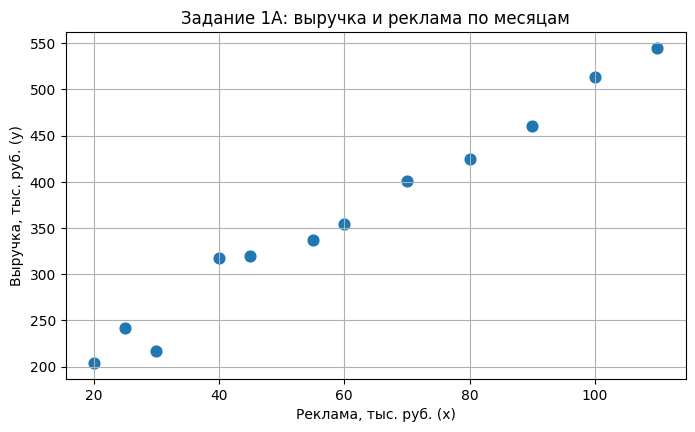

In [ ]:
# Вспомогательная ячейка: посмотрите на данные глазами, прежде чем считать
plt.scatter(ads, revenue, s=60)
plt.xlabel("Реклама, тыс. руб. (x)")
plt.ylabel("Выручка, тыс. руб. (y)")
plt.title("Задание 1А: выручка и реклама по месяцам")
plt.show()

### 1А.1 Коэффициенты модели

Подсказка: `np.polyfit(x, y, 1)` возвращает массив `[b, a]` — **сначала наклон, потом свободный член** (тот же порядок, что у `ЛИНЕЙН` в Excel). Коэффициент корреляции: `np.corrcoef(x, y)[0, 1]`.

In [ ]:
b_1a, a_1a = np.polyfit(ads, revenue, 1)       # [наклон, свободный член] — как ЛИНЕЙН
revenue_hat = a_1a + b_1a * ads
r2_1a = r_squared(revenue, revenue_hat)
r_1a = np.corrcoef(ads, revenue)[0, 1]

print(f"b = {b_1a:.3f} тыс. руб. выручки на 1 тыс. руб. рекламы")
print(f"a = {a_1a:.2f} тыс. руб.")
print(f"R² = {r2_1a:.4f},  r = {r_1a:.4f}")

b = 3.680 тыс. руб. выручки на 1 тыс. руб. рекламы
a = 139.11 тыс. руб.
R² = 0.9796,  r = 0.9897


### 1А.2 Прогноз при рекламе 150 тыс. руб.

Значение 150 лежит за пределами данных (20–110) — это экстраполяция, прогноз менее надёжен.

In [ ]:
forecast_150 = a_1a + b_1a * 150
print(f"Прогноз выручки при рекламе 150 тыс. руб.: {forecast_150:.1f} тыс. руб.")
print(f"Диапазон рекламы в данных: {ads.min():.0f}–{ads.max():.0f} тыс. руб. → 150 вне диапазона (экстраполяция)")

Прогноз выручки при рекламе 150 тыс. руб.: 691.0 тыс. руб.
Диапазон рекламы в данных: 20–110 тыс. руб. → 150 вне диапазона (экстраполяция)


### 1А.3 Диаграмма рассеяния с линией регрессии

Дорисуйте к точкам прямую модели: возьмите `xx = np.linspace(0, 160, 100)` и постройте `a + b·xx`. Подпишите оси и вынесите уравнение в легенду или заголовок.

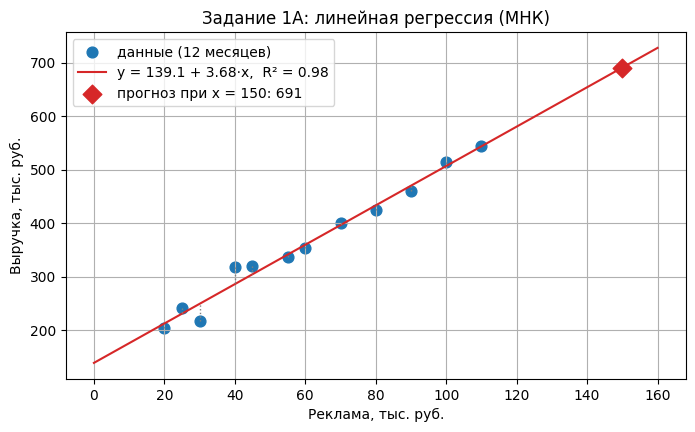

In [ ]:
xx = np.linspace(0, 160, 100)
plt.scatter(ads, revenue, s=60, label="данные (12 месяцев)")
plt.plot(xx, a_1a + b_1a * xx, color="C3", label=f"y = {a_1a:.1f} + {b_1a:.2f}·x,  R² = {r2_1a:.2f}")
plt.scatter([150], [forecast_150], marker="D", s=90, color="C3", zorder=4, label=f"прогноз при x = 150: {forecast_150:.0f}")
for x, y, yh in zip(ads, revenue, revenue_hat):          # остатки — то, что минимизирует МНК
    plt.plot([x, x], [y, yh], color="grey", ls=":", lw=1)
plt.xlabel("Реклама, тыс. руб.")
plt.ylabel("Выручка, тыс. руб.")
plt.title("Задание 1А: линейная регрессия (МНК)")
plt.legend()
plt.show()

**Ответ (1А):**

- **b ≈ 3,68**: каждая дополнительная тысяча рублей рекламы приносит в среднем ≈ 3,68 тыс. руб. выручки. **a ≈ 139**: «выручка без рекламы» (x = 0 — на границе данных, трактовать осторожно).
- **R² ≈ 0,98**: 98 % разброса выручки между месяцами объясняется различиями в рекламе; r ≈ 0,99 — связь очень тесная (но корреляция ≠ причинность).
- Прогноз при 150 (≈ 691 тыс. руб.) — **экстраполяция**: данных про такие расходы нет, линейность за пределами 110 тыс. не проверена (эффект рекламы обычно насыщается).

## Задание 1Б. Спрос на кофе от цены и рекламы (множественная регрессия)

15 недель школьное кафе меняло цену напитка `P` (руб.) и расходы на рекламу `A` (тыс. руб.) и записывало продажи `Q` (шт.).
Модель: `Q = a + b₁·P + b₂·A`.

Нужно: найти коэффициенты и R², спрогнозировать продажи при цене 100 и рекламе 5, ответить на экономический вопрос.

In [ ]:
# Данные (менять не нужно)
price = np.array([80, 85, 90, 95, 100, 100, 105, 110, 115, 120, 125, 130, 135, 140, 140], dtype=float)   # P, руб.
adv = np.array([2, 6, 3, 8, 1, 9, 4, 7, 2, 10, 5, 3, 8, 1, 6], dtype=float)                               # A, тыс. руб.
qty = np.array([559, 654, 542, 656, 424, 678, 493, 539, 378, 610, 422, 338, 475, 257, 369], dtype=float)  # Q, шт.

cafe = pd.DataFrame({"Неделя": range(1, 16), "Цена, руб. (P)": price, "Реклама, тыс. руб. (A)": adv, "Продано, шт. (Q)": qty})
cafe.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Неделя,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0
"Цена, руб. (P)",80.0,85.0,90.0,95.0,100.0,100.0,105.0,110.0,115.0,120.0,125.0,130.0,135.0,140.0,140.0
"Реклама, тыс. руб. (A)",2.0,6.0,3.0,8.0,1.0,9.0,4.0,7.0,2.0,10.0,5.0,3.0,8.0,1.0,6.0
"Продано, шт. (Q)",559.0,654.0,542.0,656.0,424.0,678.0,493.0,539.0,378.0,610.0,422.0,338.0,475.0,257.0,369.0


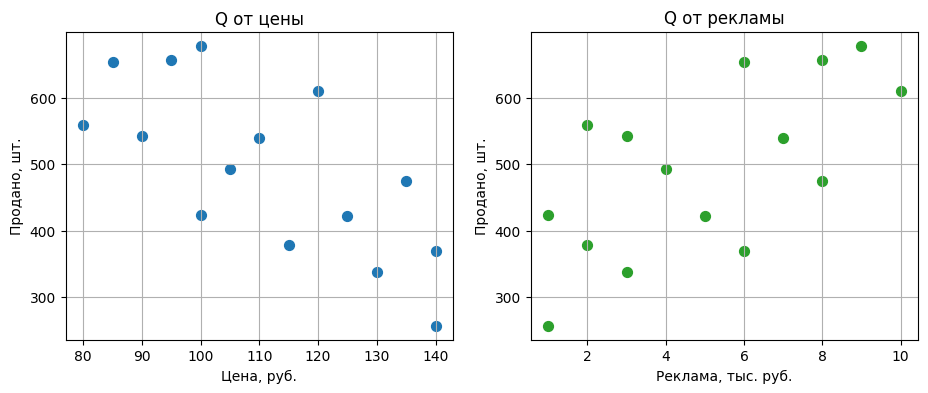

In [ ]:
# Вспомогательная ячейка: две проекции данных
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(price, qty, s=50); axes[0].set_xlabel("Цена, руб."); axes[0].set_ylabel("Продано, шт."); axes[0].set_title("Q от цены")
axes[1].scatter(adv, qty, s=50, color="C2"); axes[1].set_xlabel("Реклама, тыс. руб."); axes[1].set_ylabel("Продано, шт."); axes[1].set_title("Q от рекламы")
plt.show()

### 1Б.1 Коэффициенты множественной регрессии

Подсказка: соберите матрицу `X` из трёх столбцов — единицы (для `a`), `price`, `adv`:
`X = np.column_stack([np.ones(len(qty)), price, adv])`, затем `coef, *_ = np.linalg.lstsq(X, qty, rcond=None)` → `coef = [a, b₁, b₂]`.
(Excel-функция `ЛИНЕЙН` выдала бы тот же набор, но в обратном порядке: `b₂, b₁, a`.)

In [ ]:
X = np.column_stack([np.ones(len(qty)), price, adv])
coef, *_ = np.linalg.lstsq(X, qty, rcond=None)
a_1b, b1_price, b2_adv = coef
qty_hat = X @ coef
r2_1b = r_squared(qty, qty_hat)
print(f"Q = {a_1b:.1f} + ({b1_price:.3f})·P + {b2_adv:.2f}·A,   R² = {r2_1b:.4f}")
print(f"Рост цены на 1 руб. → спрос {b1_price:+.2f} шт.;  +1 тыс. руб. рекламы → спрос {b2_adv:+.1f} шт.")

Q = 883.4 + (-4.842)·P + 29.73·A,   R² = 0.9930
Рост цены на 1 руб. → спрос -4.84 шт.;  +1 тыс. руб. рекламы → спрос +29.7 шт.


### 1Б.2 Прогноз и экономический вопрос

Спрогнозируйте продажи при `P = 100`, `A = 5`. Затем сравните **по выручке** два решения: (а) снизить цену на 10 руб., (б) добавить 1 тыс. руб. рекламы (её стоимость вычтите из выручки).

In [ ]:
def demand(P, A):
    """Спрос по модели 1Б"""
    return a_1b + b1_price * P + b2_adv * A

q_base = demand(100, 5)
revenue_base = 100 * q_base
revenue_discount = 90 * demand(90, 5)
revenue_more_adv = 100 * demand(100, 6) - 1000
print(f"Прогноз Q(100, 5) = {q_base:.0f} шт.")
print(f"Выручка, руб.: база {revenue_base:,.0f} | скидка 10 руб. {revenue_discount:,.0f} | +1 тыс. рекламы (за вычетом её стоимости) {revenue_more_adv:,.0f}")
print(f"Рост цены на 10 руб. → спрос падает на {abs(b1_price) * 10:.0f} шт.")

Прогноз Q(100, 5) = 548 шт.
Выручка, руб.: база 54,781 | скидка 10 руб. 53,661 | +1 тыс. рекламы (за вычетом её стоимости) 56,754
Рост цены на 10 руб. → спрос падает на 48 шт.


**Ответ (1Б):**

- Рост цены на 10 руб. → спрос падает на ≈ 48 шт.; 1 тыс. руб. рекламы → +30 шт. **В штуках** скидка даёт больше.
- **В рублях** выгоднее реклама: база ≈ 54 800, скидка ≈ 53 700 (теряем 10 руб. с *каждой* проданной единицы), реклама ≈ 56 800 даже за вычетом её стоимости. Решения надо сравнивать в деньгах, а не в штуках.
- Эластичность спроса по цене в точке (100; 548): E = b₁·P/Q ≈ −0,88 — спрос неэластичный, поэтому снижение цены уменьшает выручку.

## Задание 2А. Временной ряд: выручка магазина за 2024–2025 гг.

Известна месячная выручка (тыс. руб.) за 24 месяца. Нужно спрогнозировать январь–март 2026 г. и сумму за I квартал.

Идея: вводим **номер периода** `t = 1, 2, …, 24` и строим линейный тренд `y = a + b·t` — та же регрессия, только `x` — время. Прогноз = подстановка `t = 25, 26, 27` (так работают `ПРЕДСКАЗ.ЛИНЕЙН` и `ТЕНДЕНЦИЯ`).

In [ ]:
# Данные (менять не нужно)
sales = np.array([326, 294, 321, 306, 350, 349, 359, 335, 364, 352, 359, 380,
                  391, 387, 381, 384, 424, 417, 425, 453, 414, 470, 485, 468], dtype=float)
t = np.arange(1, len(sales) + 1)
dates = pd.period_range("2024-01", periods=len(sales), freq="M")
ts_df = pd.DataFrame({"Месяц": dates.astype(str), "t": t, "Выручка, тыс. руб.": sales})
ts_df.T

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Месяц,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,...,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
t,1,2,3,4,5,6,7,8,9,10,...,15,16,17,18,19,20,21,22,23,24
"Выручка, тыс. руб.",326.0,294.0,321.0,306.0,350.0,349.0,359.0,335.0,364.0,352.0,...,381.0,384.0,424.0,417.0,425.0,453.0,414.0,470.0,485.0,468.0


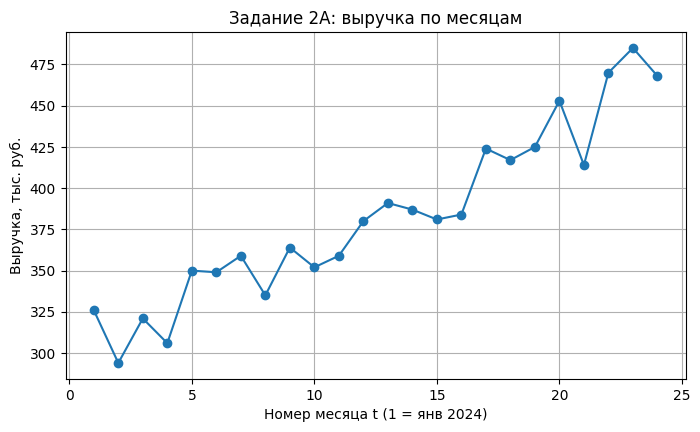

In [ ]:
# Вспомогательная ячейка: график ряда
plt.plot(t, sales, marker="o")
plt.xlabel("Номер месяца t (1 = янв 2024)")
plt.ylabel("Выручка, тыс. руб.")
plt.title("Задание 2А: выручка по месяцам")
plt.show()

### 2А.1 Линейный тренд и прогноз на I квартал 2026

In [ ]:
b_2a, a_2a = np.polyfit(t, sales, 1)
r2_2a = r_squared(sales, a_2a + b_2a * t)
t_new = np.array([25, 26, 27])
forecast_q1 = a_2a + b_2a * t_new          # аналог ТЕНДЕНЦИЯ(известные_y; известные_x; новые_x)
total_q1 = forecast_q1.sum()
forecast_dec_2026 = a_2a + b_2a * 36

print(f"Тренд: y = {a_2a:.1f} + {b_2a:.3f}·t   (средний рост ≈ {b_2a:.1f} тыс. руб. в месяц),  R² = {r2_2a:.3f}")
for month, value in zip(["янв 2026", "фев 2026", "мар 2026"], forecast_q1):
    print(f"  {month}: {value:.1f}")
print(f"Итого за I кв. 2026: {total_q1:.0f} тыс. руб.")
print(f"Прогноз на декабрь 2026 (t = 36): {forecast_dec_2026:.1f}")
print(f"Прогноз на t = 60 (через 3 года): {a_2a + b_2a * 60:.0f} — формула выдаёт, но верить нельзя")

Тренд: y = 294.5 + 7.085·t   (средний рост ≈ 7.1 тыс. руб. в месяц),  R² = 0.906
  янв 2026: 471.6
  фев 2026: 478.7
  мар 2026: 485.8
Итого за I кв. 2026: 1436 тыс. руб.
Прогноз на декабрь 2026 (t = 36): 549.6
Прогноз на t = 60 (через 3 года): 720 — формула выдаёт, но верить нельзя


### 2А.2 График с трендом и прогнозом

Нарисуйте факт, линию тренда, продлённую до t = 27, и точки прогноза другим маркером.

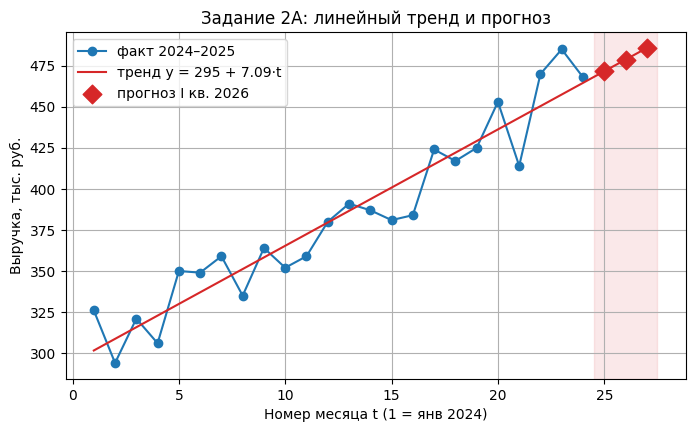

In [ ]:
tt = np.arange(1, 28)
plt.plot(t, sales, marker="o", label="факт 2024–2025")
plt.plot(tt, a_2a + b_2a * tt, color="C3", label=f"тренд y = {a_2a:.0f} + {b_2a:.2f}·t")
plt.scatter(t_new, forecast_q1, marker="D", s=90, color="C3", zorder=4, label="прогноз I кв. 2026")
plt.axvspan(24.5, 27.5, color="C3", alpha=0.1)
plt.xlabel("Номер месяца t (1 = янв 2024)")
plt.ylabel("Выручка, тыс. руб.")
plt.title("Задание 2А: линейный тренд и прогноз")
plt.legend()
plt.show()

**Ответ (2А):**

- Средний рост ≈ **7,1 тыс. руб. в месяц**, R² ≈ 0,91 — тренд устойчивый.
- Прогноз: янв ≈ 472, фев ≈ 479, мар ≈ 486 → **I кв. 2026 ≈ 1 436 тыс. руб.**
- Прогноз на t = 60 (≈ 720) — экстраполяция на 3 года по 2 годам данных: предполагает неизменность условий (рынок, конкуренты, инфляция, ёмкость спроса), а погрешность растёт с удалением от данных. Разумный горизонт — 10–20 % длины ряда, т. е. 2–5 месяцев.

## Задание 2Б (*). Сезонность: квартальные продажи мороженого

12 кварталов продаж (шт.). Проверьте, годится ли линейный тренд, и постройте прогноз на 4 квартала 2026 г. с учётом сезонности.

Простой метод **сезонных индексов**:
1. индекс квартала k = (средние продажи в кварталах k) / (общее среднее);
2. ряд «без сезона» = продажи / индекс своего квартала;
3. линейный тренд по ряду без сезона;
4. прогноз = тренд(t) × индекс квартала.

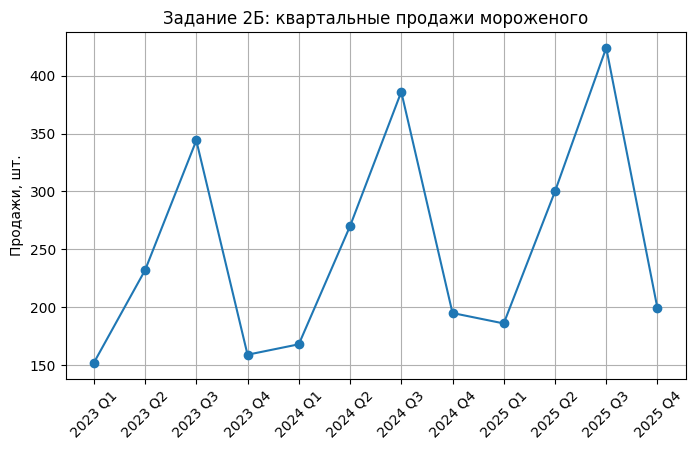

In [ ]:
# Данные (менять не нужно)
ice = np.array([152, 232, 344, 159, 168, 270, 386, 195, 186, 300, 424, 199], dtype=float)
tq = np.arange(1, 13)
quarter = (tq - 1) % 4                      # 0,1,2,3 — номер квартала внутри года
labels_q = [f"{2023 + (k - 1) // 4} Q{(k - 1) % 4 + 1}" for k in tq]

plt.plot(tq, ice, marker="o")
plt.xticks(tq, labels_q, rotation=45)
plt.ylabel("Продажи, шт.")
plt.title("Задание 2Б: квартальные продажи мороженого")
plt.show()

R² линейного тренда по исходному ряду: 0.095  ← тренд объясняет < 10 % разброса
Сезонные индексы Q1..Q4: [0.67 1.06 1.53 0.73]  (лето ×1.5, зима ×0.7)
Линейный прогноз 2026 Q1..Q4: [303. 311. 319. 327.]
Сезонный прогноз 2026 Q1..Q4: [196. 317. 465. 227.]


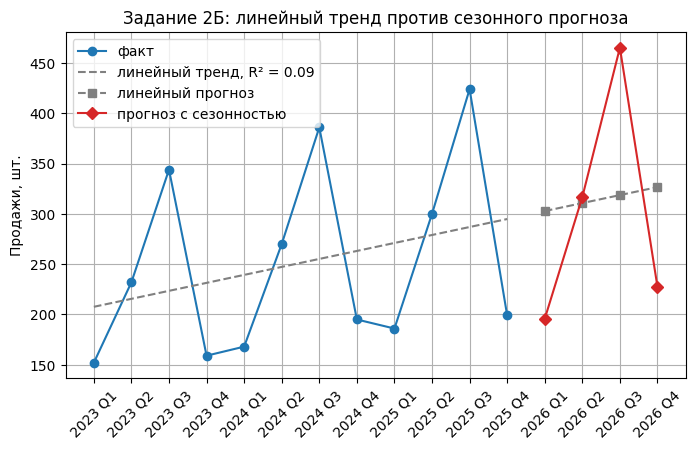

In [ ]:
b_lin, a_lin = np.polyfit(tq, ice, 1)
r2_lin = r_squared(ice, a_lin + b_lin * tq)

season_index = np.array([ice[quarter == k].mean() for k in range(4)]) / ice.mean()
ice_deseason = ice / season_index[quarter]
b_s, a_s = np.polyfit(tq, ice_deseason, 1)

t_future = np.array([13, 14, 15, 16])
forecast_linear = a_lin + b_lin * t_future
forecast_season = (a_s + b_s * t_future) * season_index[(t_future - 1) % 4]

print(f"R² линейного тренда по исходному ряду: {r2_lin:.3f}  ← тренд объясняет < 10 % разброса")
print("Сезонные индексы Q1..Q4:", season_index.round(2), " (лето ×1.5, зима ×0.7)")
print("Линейный прогноз 2026 Q1..Q4:", forecast_linear.round(0))
print("Сезонный прогноз 2026 Q1..Q4:", forecast_season.round(0))

plt.plot(tq, ice, marker="o", label="факт")
plt.plot(tq, a_lin + b_lin * tq, ls="--", color="grey", label=f"линейный тренд, R² = {r2_lin:.2f}")
plt.plot(t_future, forecast_linear, "s--", color="grey", label="линейный прогноз")
plt.plot(t_future, forecast_season, "D-", color="C3", label="прогноз с сезонностью")
plt.xticks(list(tq) + list(t_future), labels_q + [f"2026 Q{k}" for k in range(1, 5)], rotation=45)
plt.ylabel("Продажи, шт.")
plt.title("Задание 2Б: линейный тренд против сезонного прогноза")
plt.legend()
plt.show()

**Ответ (2Б):** линейный тренд даёт одинаково «серые» ≈ 303–327 шт. на все кварталы (R² ≈ 0,09) — прямая проходит посередине зубцов. Сезонный прогноз (≈ 196 / 317 / 465 / 228) воспроизводит летний пик и зимний спад. Прежде чем прогнозировать — посмотри на график. (В Excel это делает `ПРЕДСКАЗ.ETS`; в Python — `statsmodels.tsa.holtwinters.ExponentialSmoothing`.)

## Задание 3. Анализ «что если»: модель прибыли школьного кафе

Спрос линейно зависит от цены: `Q = a − b·P` (коэффициенты получены регрессией, как в 1Б). Параметры базового варианта:

| Параметр | Обозначение | Значение |
|---|---|---|
| Цена напитка, руб. | P | 150 |
| Базовый спрос, шт./мес. | a | 2000 |
| Падение спроса на 1 руб. цены, шт./руб. | b | 8 |
| Переменные затраты на напиток, руб. | VC | 60 |
| Постоянные затраты (аренда, зарплата), руб./мес. | FC | 40 000 |

Прибыль = `(P − VC)·Q − FC`. Сначала оформите модель **функцией** с параметрами по умолчанию — тогда любой вопрос «что если» сводится к вызову функции с другими аргументами.

In [ ]:
def demand_q(P, a=2000, b=8):
    """Спрос Q = a − b·P"""
    return a - b * P

def profit(P=150, a=2000, b=8, VC=60, FC=40_000):
    """Прибыль за месяц = (P − VC)·Q − FC"""
    Q = demand_q(P, a, b)
    return (P - VC) * Q - FC

print(f"Базовый вариант: Q = {demand_q(150):.0f} шт., выручка = {150 * demand_q(150):,.0f} руб., прибыль = {profit():,.0f} руб.")

Базовый вариант: Q = 800 шт., выручка = 120,000 руб., прибыль = 32,000 руб.


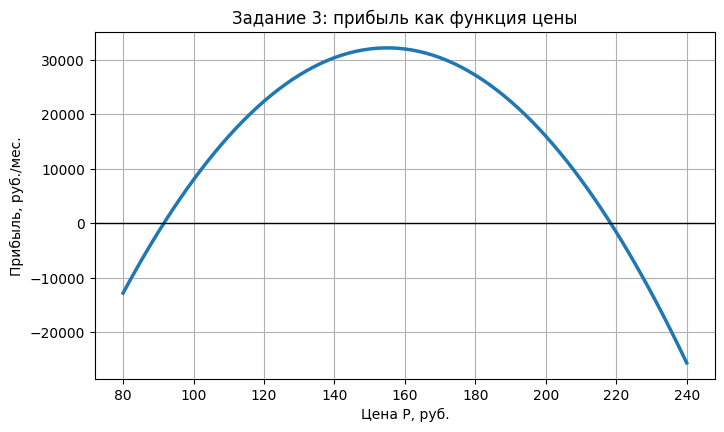

In [ ]:
# Вспомогательная ячейка: как прибыль зависит от цены (при остальных параметрах базовых)
pp = np.linspace(80, 240, 161)
plt.plot(pp, [profit(P) for P in pp], lw=2.5)
plt.axhline(0, color="black", lw=1)
plt.xlabel("Цена P, руб.")
plt.ylabel("Прибыль, руб./мес.")
plt.title("Задание 3: прибыль как функция цены")
plt.show()

### 3.1–3.3 Подбор параметра (обратная задача)

`goal_seek(func, target, lo, hi)` ищет `x` на отрезке `[lo, hi]`, при котором `func(x) == target`. Функцию одной переменной удобно задать `lambda`: например, `lambda P: profit(P)`.

- **3.1** При какой цене прибыль = 30 000? Поищите на отрезках `[100, 155]` и `[155, 250]` — сколько решений?
- **3.2** При P = 150 — какие максимальные постоянные затраты FC допустимы, чтобы прибыль была ≥ 0?
- **3.3** Цены безубыточности (прибыль = 0) при FC = 40 000 — нижняя и верхняя.

In [ ]:
price_for_30k_low = goal_seek(lambda P: profit(P), 30_000, 100, 155)
price_for_30k_high = goal_seek(lambda P: profit(P), 30_000, 155, 250)
max_fc = goal_seek(lambda FC: profit(P=150, FC=FC), 0, 0, 200_000)
breakeven_low = goal_seek(lambda P: profit(P), 0, 60, 155)
breakeven_high = goal_seek(lambda P: profit(P), 0, 155, 250)

print(f"3.1 Цена для прибыли 30 000: {price_for_30k_low:.1f} руб. или {price_for_30k_high:.1f} руб. — два решения!")
print(f"    проверка: profit({price_for_30k_low:.1f}) = {profit(price_for_30k_low):,.0f}")
print(f"3.2 Максимальные постоянные затраты при P = 150: {max_fc:,.0f} руб. (= (150 − 60)·800)")
print(f"3.3 Цены безубыточности при FC = 40 000: {breakeven_low:.1f} и {breakeven_high:.1f} руб. — между ними бизнес прибылен")

# Аналитическая проверка: (P − 60)(2000 − 8P) − 40000 = 30000  ⇔  P² − 310P + 23750 = 0
d = 310**2 - 4 * 23750
print(f"    аналитически: P = {(310 - d**0.5) / 2:.1f} и {(310 + d**0.5) / 2:.1f}")

3.1 Цена для прибыли 30 000: 138.4 руб. или 171.6 руб. — два решения!
    проверка: profit(138.4) = 30,000
3.2 Максимальные постоянные затраты при P = 150: 72,000 руб. (= (150 − 60)·800)
3.3 Цены безубыточности при FC = 40 000: 91.6 и 218.4 руб. — между ними бизнес прибылен
    аналитически: P = 138.4 и 171.6


**Ответ (3.1–3.3):** прибыль — парабола по цене, поэтому уровень 30 000 достигается при двух ценах (≈ 138 и ≈ 172). Excel-«Подбор параметра» нашёл бы ту, что ближе к стартовому значению. Выбор — управленческий: ниже цена → больше клиентов и доля рынка, выше → меньше нагрузка на точку. Цены безубыточности ≈ 92 и ≈ 218 руб.: дешевле — не покрываем затраты объёмом, дороже — теряем спрос. Допустимые постоянные затраты при P = 150 — не более 72 000 руб.

### 3.4 Таблица данных с одной переменной: чувствительность прибыли к цене

Постройте `DataFrame` для цен 100, 110, …, 220 со столбцами «Спрос», «Выручка», «Прибыль». Найдите цену с максимальной прибылью, затем уточните шагом 5 руб. (или 1 руб.) вокруг неё.

In [ ]:
prices = np.arange(100, 221, 10)
table_1d = pd.DataFrame({
    "Спрос, шт.": [demand_q(P) for P in prices],
    "Выручка, руб.": [P * demand_q(P) for P in prices],
    "Прибыль, руб.": [profit(P) for P in prices],
}, index=pd.Index(prices, name="Цена P, руб."))

best_price_rough = table_1d["Прибыль, руб."].idxmax()
fine = np.arange(140, 171, 1)
best_price_exact = fine[np.argmax([profit(P) for P in fine])]
print(f"Грубо (шаг 10): максимум {table_1d['Прибыль, руб.'].max():,.0f} при P = {best_price_rough} (и соседней цене — максимум между ними)")
print(f"Точно (шаг 1):  P* = {best_price_exact}, прибыль = {profit(best_price_exact):,.0f}  ← формула P* = (a/b + VC)/2 = {(2000 / 8 + 60) / 2:.0f}")
table_1d.style.format("{:,.0f}").highlight_max(subset=["Прибыль, руб."], color="#C6EFCE")

Грубо (шаг 10): максимум 32,000 при P = 150 (и соседней цене — максимум между ними)
Точно (шаг 1):  P* = 155, прибыль = 32,200  ← формула P* = (a/b + VC)/2 = 155


,"Спрос, шт.","Выручка, руб.","Прибыль, руб."
"Цена P, руб.",,,
100,"1,200","120,000","8,000"
110,"1,120","123,200","16,000"
120,"1,040","124,800","22,400"
130,960,"124,800","27,200"
140,880,"123,200","30,400"
150,800,"120,000","32,000"
160,720,"115,200","32,000"
170,640,"108,800","30,400"
180,560,"100,800","27,200"


### 3.5 Таблица данных с двумя переменными: цена × переменные затраты

Строки — цены 100…220 (шаг 10), столбцы — VC = 40, 50, 60, 70, 80; в ячейках — прибыль. Выделите убыточные сочетания (прибыль < 0) цветом: `table.style.map(lambda v: "color: red" if v < 0 else "")`.

Лучшая цена при каждом VC (шаг 10): {40: 140, 50: 150, 60: 150, 70: 160, 80: 160}
Рост VC на 10 руб. сдвигает оптимальную цену примерно на +5 руб.  (P* = (a/b + VC)/2)


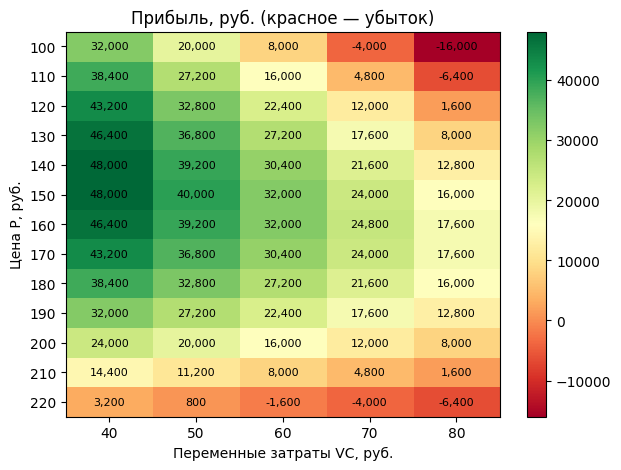

"VC, руб.",40,50,60,70,80
Цена P ↓ / VC →,,,,,
100,"32,000","20,000","8,000","-4,000","-16,000"
110,"38,400","27,200","16,000","4,800","-6,400"
120,"43,200","32,800","22,400","12,000","1,600"
130,"46,400","36,800","27,200","17,600","8,000"
140,"48,000","39,200","30,400","21,600","12,800"
150,"48,000","40,000","32,000","24,000","16,000"
160,"46,400","39,200","32,000","24,800","17,600"
170,"43,200","36,800","30,400","24,000","17,600"
180,"38,400","32,800","27,200","21,600","16,000"


In [ ]:
vcs = [40, 50, 60, 70, 80]
table_2d = pd.DataFrame({vc: [profit(P, VC=vc) for P in prices] for vc in vcs},
                        index=pd.Index(prices, name="Цена P ↓ / VC →"))
table_2d.columns.name = "VC, руб."

best_by_vc = table_2d.idxmax()
print("Лучшая цена при каждом VC (шаг 10):", {vc: int(p) for vc, p in best_by_vc.items()})
print("Рост VC на 10 руб. сдвигает оптимальную цену примерно на +5 руб.  (P* = (a/b + VC)/2)")

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(table_2d.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(vcs)), vcs); ax.set_yticks(range(len(prices)), prices)
ax.set_xlabel("Переменные затраты VC, руб."); ax.set_ylabel("Цена P, руб."); ax.set_title("Прибыль, руб. (красное — убыток)")
for i in range(len(prices)):
    for j in range(len(vcs)):
        ax.text(j, i, f"{table_2d.values[i, j]:,.0f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax)
plt.grid(False)
plt.show()

table_2d.style.format("{:,.0f}").map(lambda v: "color: red; font-weight: bold" if v < 0 else "")

### 3.6 Сценарии

Три набора параметров — соберите сводную таблицу «сценарий → спрос, выручка, прибыль» при P = 150:

| Сценарий | a | VC | FC |
|---|---|---|---|
| Пессимистичный | 1800 | 70 | 45 000 |
| Базовый | 2000 | 60 | 40 000 |
| Оптимистичный | 2200 | 55 | 40 000 |

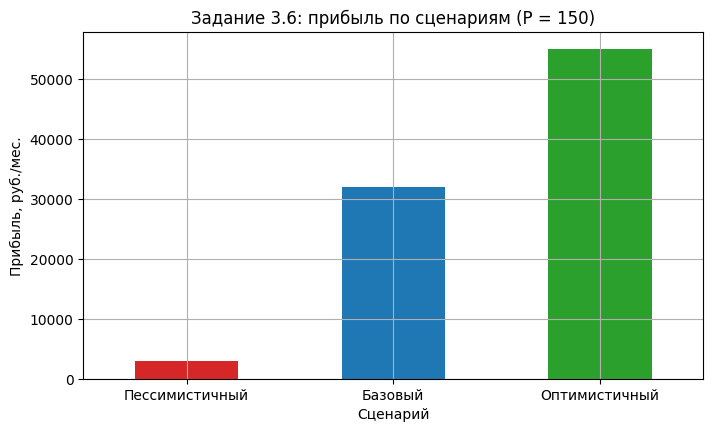

,a,VC,FC,"Спрос, шт.","Выручка, руб.","Прибыль, руб."
Сценарий,,,,,,
Пессимистичный,"1,800",70,"45,000",600,"90,000","3,000"
Базовый,"2,000",60,"40,000",800,"120,000","32,000"
Оптимистичный,"2,200",55,"40,000","1,000","150,000","55,000"


In [ ]:
scenarios = {
    "Пессимистичный": dict(a=1800, VC=70, FC=45_000),
    "Базовый":        dict(a=2000, VC=60, FC=40_000),
    "Оптимистичный":  dict(a=2200, VC=55, FC=40_000),
}
rows = []
for name, params in scenarios.items():
    Q = demand_q(150, a=params["a"])
    rows.append({"Сценарий": name, **params, "Спрос, шт.": Q, "Выручка, руб.": 150 * Q, "Прибыль, руб.": profit(P=150, **params)})
scenario_table = pd.DataFrame(rows).set_index("Сценарий")

scenario_table["Прибыль, руб."].plot(kind="bar", color=["C3", "C0", "C2"], rot=0)
plt.ylabel("Прибыль, руб./мес."); plt.title("Задание 3.6: прибыль по сценариям (P = 150)")
plt.show()
scenario_table.style.format("{:,.0f}")

## Итог. Рекомендация управленца (пример ответа)

**Ответ:** Назначить цену **≈ 155 руб.** (максимум прибыли ≈ 32 200 руб./мес.; диапазон 150–160 почти равноценен). Бизнес остаётся прибыльным при цене от **92 до 218 руб.**; постоянные затраты (аренда + зарплата) не должны превышать **72 000 руб./мес.** при цене 150. В пессимистичном сценарии (спрос −10 %, VC 70, аренда 45 000) прибыль падает до **3 000 руб.** — нужен резерв или план снижения переменных затрат, так как каждые +10 руб. VC съедают ≈ 8 000 руб. прибыли.

---
*Конец решения. Проверка работ учеников — по файлу `Практикум_критерии.json`.*